# 04 — The real SH basis that graphics actually uses

This is the notebook to bookmark. Everything from here on — projection,
irradiance, shader code — is written against the **real** basis derived here.

By the end you will have the nine polynomials that ship in every engine, know
where each constant comes from, and be able to write the shader function from
memory.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

## 1. Folding $\pm m$ into real pairs

Notebook 03 ended with the redundancy $Y_\ell^{-m} = (-1)^m\overline{Y_\ell^m}$. A
complex conjugate pair contains exactly two real numbers' worth of information, so
recombine them into two real functions using
$\cos = \frac{e^{i\alpha}+e^{-i\alpha}}{2}$ and $\sin = \frac{e^{i\alpha}-e^{-i\alpha}}{2i}$:

$$y_\ell^m = \begin{cases}
\sqrt{2}\,K_\ell^m\,\cos(m\phi)\,P_\ell^{m}(\cos\theta) & m > 0\\[4pt]
K_\ell^0\,P_\ell^{0}(\cos\theta) & m = 0\\[4pt]
\sqrt{2}\,K_\ell^{|m|}\,\sin(|m|\phi)\,P_\ell^{|m|}(\cos\theta) & m < 0
\end{cases}$$

Two details worth understanding rather than memorising:

- **The $\sqrt{2}$** preserves normalisation. Splitting one unit-energy complex
  function into two real ones would otherwise leave each with half the energy;
  $\sqrt{2}$ puts it back.
- **$m=0$ has no $\sqrt{2}$** because $Y_\ell^0$ is already real — there is no pair
  to fold, nothing was split.

The result is $2\ell+1$ real, orthonormal functions per band, spanning exactly the
same space as before.

In [2]:
# Implement it from scratch, then check against shlib.
def real_sh(l, m, theta, phi):
    k = sh.sh_normalization(l, m)
    P = sh.assoc_legendre(l, abs(m), np.cos(theta))
    if m > 0:
        return np.sqrt(2) * k * np.cos(m * phi) * P
    if m < 0:
        return np.sqrt(2) * k * np.sin(-m * phi) * P
    return k * P

d = sh.fibonacci_sphere(20_000)
th, ph = sh.spherical_from_dir(d)

mine = np.stack([real_sh(l, m, th, ph) for l in range(5) for m in range(-l, l+1)], axis=1)
lib  = sh.sh_eval_dirs(4, d)
print(f"hand-rolled vs shlib.sh_eval:  max difference {np.abs(mine - lib).max():.2e}")

hand-rolled vs shlib.sh_eval:  max difference 0.00e+00


max |G - I| over 25 basis functions:  7.03e-08


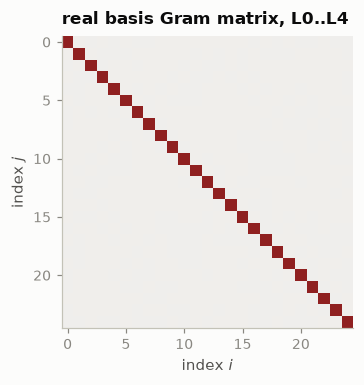

In [3]:
# And confirm orthonormality of the real basis directly.
N = 400_000
d = sh.fibonacci_sphere(N)
Y = sh.sh_eval_dirs(4, d)                 # (N, 25)
G = (4*np.pi/N) * (Y.T @ Y)
print(f"max |G - I| over 25 basis functions:  {np.abs(G - np.eye(25)).max():.2e}")

fig, ax = plt.subplots(figsize=(4.0, 3.6))
ax.imshow(G, cmap=sp.CM_DIVERGING, vmin=-1, vmax=1)
ax.set_title("real basis Gram matrix, L0..L4")
ax.set_xlabel("index $i$"); ax.set_ylabel("index $j$"); ax.grid(False)
fig.tight_layout()

## 2. The nine polynomials

For $\ell \le 2$ the trigonometry collapses into plain polynomials in the direction
components $(x, y, z)$. **This is the form used in shaders** — no trig, no
Legendre, just multiplies.

| $i$ | $(\ell,m)$ | $y_i(x,y,z)$ | constant |
|---|---|---|---|
| 0 | $(0,0)$ | $c$ | $0.282095 = \tfrac12\sqrt{1/\pi}$ |
| 1 | $(1,-1)$ | $c\,y$ | $0.488603 = \tfrac12\sqrt{3/\pi}$ |
| 2 | $(1,0)$ | $c\,z$ | $0.488603$ |
| 3 | $(1,1)$ | $c\,x$ | $0.488603$ |
| 4 | $(2,-2)$ | $c\,xy$ | $1.092548 = \tfrac12\sqrt{15/\pi}$ |
| 5 | $(2,-1)$ | $c\,yz$ | $1.092548$ |
| 6 | $(2,0)$ | $c\,(3z^2-1)$ | $0.315392 = \tfrac14\sqrt{5/\pi}$ |
| 7 | $(2,1)$ | $c\,xz$ | $1.092548$ |
| 8 | $(2,2)$ | $c\,(x^2-y^2)$ | $0.546274 = \tfrac14\sqrt{15/\pi}$ |

Read the structure: band 0 is a **constant** (average light). Band 1 is **linear**
in the direction — a gradient, "brighter this way". Band 2 is **quadratic** —
it can describe light from two opposing directions at once, which a linear term
cannot.

That progression is the physical meaning of the bands, and it is worth holding onto:
*constant, then directional, then squeeze-along-an-axis.*

In [4]:
# Verify the table against the general implementation. If this passes,
# shader code written from the table will agree with the math.
d = sh.fibonacci_sphere(5000)
x, y, z = d[:, 0], d[:, 1], d[:, 2]

table = {
    (0, 0):  0.282095 * np.ones_like(x),
    (1,-1):  0.488603 * y,
    (1, 0):  0.488603 * z,
    (1, 1):  0.488603 * x,
    (2,-2):  1.092548 * x * y,
    (2,-1):  1.092548 * y * z,
    (2, 0):  0.315392 * (3*z*z - 1),
    (2, 1):  1.092548 * x * z,
    (2, 2):  0.546274 * (x*x - y*y),
}
B = sh.sh_eval_dirs(2, d)
print(f"{'(l,m)':>8}{'max abs error':>16}")
print("-" * 25)
for (l, m), ref in table.items():
    print(f"{f'({l},{m})':>8}{np.abs(B[:, sh.sh_index(l,m)] - ref).max():>16.2e}")

   (l,m)   max abs error
-------------------------
   (0,0)        2.08e-07
  (1,-1)        4.88e-07
   (1,0)        4.88e-07
   (1,1)        4.88e-07
  (2,-2)        2.15e-07
  (2,-1)        2.15e-07
   (2,0)        8.69e-07
   (2,1)        2.15e-07
   (2,2)        2.15e-07


### Where those constants come from

Nothing is arbitrary. Take $y_1^1$: $K_1^1 = \sqrt{\frac{3}{4\pi}\cdot\frac{0!}{2!}} = \sqrt{\frac{3}{8\pi}}$,
$P_1^1(\cos\theta) = \sin\theta$, and the $m>0$ branch adds $\sqrt{2}\cos\phi$:

$$y_1^1 = \sqrt{2}\sqrt{\tfrac{3}{8\pi}}\,\sin\theta\cos\phi = \sqrt{\tfrac{3}{4\pi}}\;x = 0.488603\,x$$

since $\sin\theta\cos\phi$ *is* $x$.

In [5]:
print(f"sqrt(2)*K(1,1)     = {np.sqrt(2)*sh.sh_normalization(1,1):.6f}")
print(f"0.5*sqrt(3/pi)     = {0.5*np.sqrt(3/np.pi):.6f}")
print(f"sqrt(2)*K(2,2)*3   = {np.sqrt(2)*sh.sh_normalization(2,2)*3:.6f}")
print(f"0.25*sqrt(15/pi)*2 = {0.5*np.sqrt(15/np.pi):.6f}   <- y(2,2) coefficient")

sqrt(2)*K(1,1)     = 0.488603
0.5*sqrt(3/pi)     = 0.488603
sqrt(2)*K(2,2)*3   = 0.546274
0.25*sqrt(15/pi)*2 = 1.092548   <- y(2,2) coefficient


## 3. Seeing the basis

The classic picture: plot $|y_\ell^m|$ as a radius and colour by sign. Blue is
positive, red negative.

Text(0.02, 1.01, 'The nine L2 basis functions — blue positive, red negative')

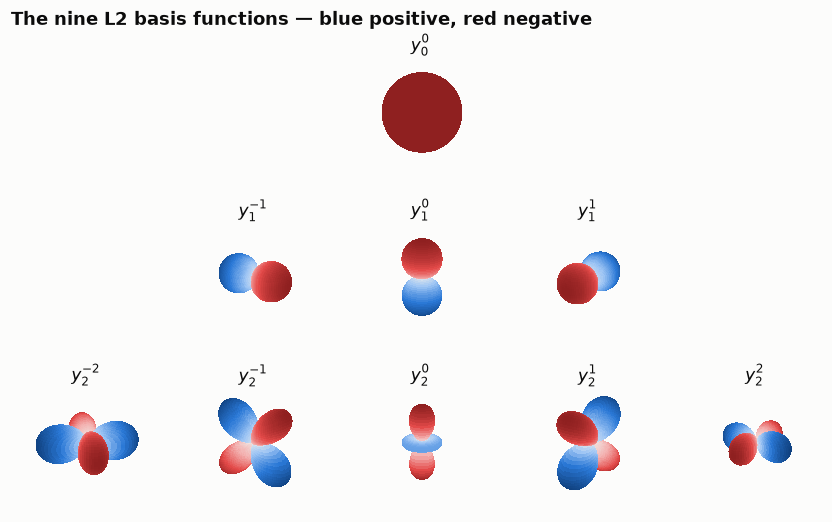

In [6]:
fig = sp.basis_grid(lmax=2, res=64, size=1.55)
fig.suptitle("The nine L2 basis functions — blue positive, red negative",
             y=1.01, x=0.02, ha="left", fontsize=12, weight="bold")

(<Figure size 1320x726 with 18 Axes>,
 array([[<Axes: title={'left': '$y_{0}^{0}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': '$y_{1}^{-1}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': '$y_{1}^{0}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>],
        [<Axes: title={'left': '$y_{1}^{1}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': '$y_{2}^{-2}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': '$y_{2}^{-1}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>],
        [<Axes: title={'left': '$y_{2}^{0}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': '$y_{2}^{1}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': '$y_{2}^{2}$'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>]],
 

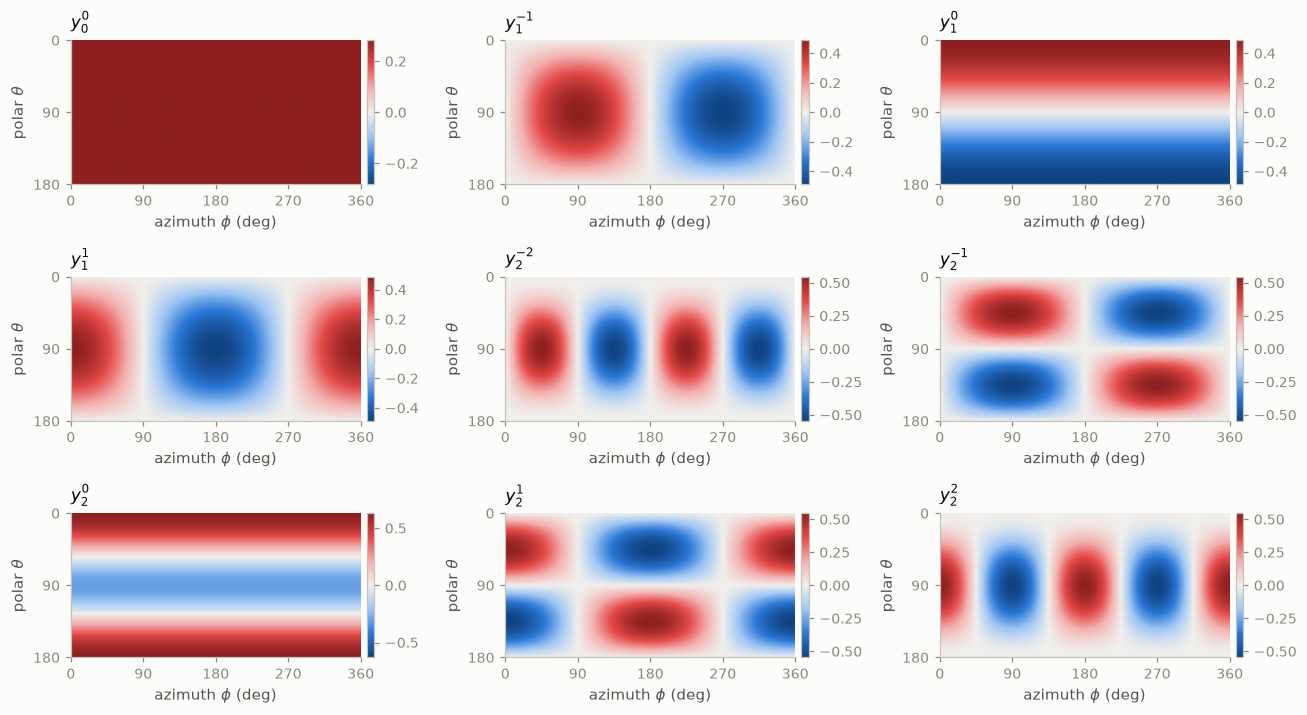

In [7]:
# The same functions as equirectangular maps -- easier to read quantitatively.
imgs, titles = [], []
for l in range(3):
    for m in range(-l, l+1):
        idx = sh.sh_index(l, m)
        imgs.append(sh.sh_to_equirect(np.eye(9)[idx], 200, 100))
        titles.append(f"$y_{{{l}}}^{{{m}}}$")
sp.show_images(imgs, titles, cols=3, signed=True, share_scale=False,
               figsize=(12.0, 6.6))

Reading these: band 1 splits the sphere in half along one axis — a pure gradient.
Band 2's $m=\pm2, \pm1$ terms make four-lobed cloverleaves, and $y_2^0$ makes the
distinctive "up *and* down are bright, the equator is dark" pattern.

Higher bands just add more lobes:

Text(0.02, 1.01, 'Adding band 3 — more lobes, higher angular frequency')

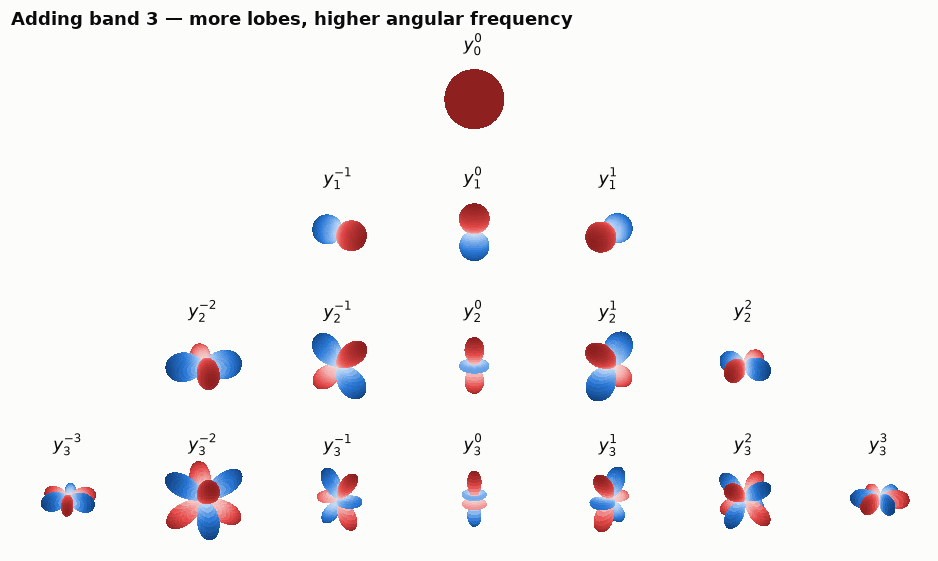

In [8]:
fig = sp.basis_grid(lmax=3, res=52, size=1.25)
fig.suptitle("Adding band 3 — more lobes, higher angular frequency",
             y=1.01, x=0.02, ha="left", fontsize=12, weight="bold")

## 4. Evaluating the basis in a shader

The polynomial table translates directly. Here is the unrolled L2 evaluation as it
appears in real code — this exact function is in essentially every engine:

```hlsl
// Evaluate the 9 real SH basis functions for a unit direction n.
void SHEvalL2(float3 n, out float y[9])
{
    y[0] =  0.282095;
    y[1] =  0.488603 * n.y;
    y[2] =  0.488603 * n.z;
    y[3] =  0.488603 * n.x;
    y[4] =  1.092548 * n.x * n.y;
    y[5] =  1.092548 * n.y * n.z;
    y[6] =  0.315392 * (3.0 * n.z * n.z - 1.0);
    y[7] =  1.092548 * n.x * n.z;
    y[8] =  0.546274 * (n.x * n.x - n.y * n.y);
}
```

Note the ordering: index $= \ell^2 + \ell + m$. That layout is universal, so
coefficient arrays are portable between codebases even when conventions differ
elsewhere.

**The up-axis caveat.** Written this way the code assumes *this notebook's* Z-up
convention. In a Y-up engine you either swizzle the direction before calling, or
rewrite the table with `y` and `z` exchanged. Getting this wrong produces lighting
that looks plausible but is rotated 90° — one of the harder bugs to spot by eye.
Notebook 07 covers it properly.

In [9]:
# Prove the shader-style unrolled version matches the general one.
def sh_eval_l2_unrolled(n):
    x, y, z = n[..., 0], n[..., 1], n[..., 2]
    return np.stack([
        np.full_like(x, 0.282095),
        0.488603 * y,
        0.488603 * z,
        0.488603 * x,
        1.092548 * x * y,
        1.092548 * y * z,
        0.315392 * (3*z*z - 1),
        1.092548 * x * z,
        0.546274 * (x*x - y*y),
    ], axis=-1)

d = sh.fibonacci_sphere(10_000)
print(f"unrolled vs general:  max difference "
      f"{np.abs(sh_eval_l2_unrolled(d) - sh.sh_eval_dirs(2, d)).max():.2e}")

unrolled vs general:  max difference 8.69e-07


## 5. Projection and reconstruction, end to end

With an orthonormal basis, both directions are one line each:

$$c_i = \int_{S^2} f(\boldsymbol\omega)\,y_i(\boldsymbol\omega)\,d\omega
\qquad\qquad
f(\boldsymbol\omega) \approx \sum_i c_i\,y_i(\boldsymbol\omega)$$

**Baking a light probe is the left equation. Reading one in a shader is the
right.** That is genuinely all a light probe is.

(<Figure size 1650x275 with 5 Axes>,
 array([[<Axes: title={'left': 'original environment'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'L0 — 1 coefficients'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'L1 — 4 coefficients'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'L2 — 9 coefficients'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'L4 — 25 coefficients'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>]],
       dtype=object))

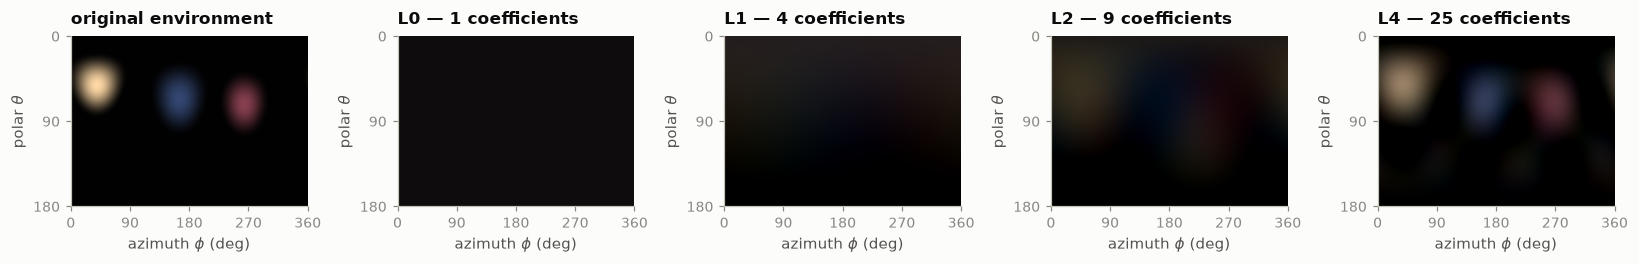

In [10]:
import shscene as ss

# Project a real environment and watch the reconstruction improve band by band.
env = ss.sky_studio
c = sh.project_env(env, 6, n_samples=300_000)

truth = sh.env_to_equirect(env, 240, 120)
imgs = [truth / truth.max()]
titles = ["original environment"]
for L in (0, 1, 2, 4):
    rec = sh.sh_to_equirect(c[:(L+1)**2], 240, 120)
    imgs.append(np.clip(rec / truth.max(), 0, 1))
    titles.append(f"L{L} — {(L+1)**2} coefficients")

sp.show_images(imgs, titles, cols=5, figsize=(15.0, 2.5))

L0 is a flat average. L1 adds the dominant direction. L2 starts resolving
individual lights. L4 is recognisable but still soft — those lights are *sharp*,
and sharp means high frequency.

This looks like bad news for a 9-coefficient light probe, and if we needed to
reconstruct **radiance** it would be. We do not. Notebook 06 is where that turns
around.

---

**Next:** [05 — Projection, truncation, and ringing](05_projection_and_ringing.ipynb)